In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [22]:
df=pd.read_csv('cleaned_nepali_houses_v3.csv')
temp_df=df.copy()

In [9]:
df.columns


Index(['category', 'title', 'district', 'neighborhood', 'location_raw',
       'total_price', 'price_per_aana', 'land_area_aana', 'build_up_area',
       'floors', 'facing', 'road_width_feet', 'bedrooms', 'bathrooms',
       'parking_cars', 'parking_bikes', 'built_year_ad', 'house_age',
       'is_under_construction', 'amenity_count', 'has_modular_kitchen',
       'has_parquet', 'has_drainage', 'has_solar', 'has_parking', 'has_garden',
       'is_wide_road', 'is_commercial_suspect', 'is_area_estimated',
       'luxury_score'],
      dtype='object')

In [16]:
pd.set_option('display.max_columns',None)

In [29]:
df.shape

(2629, 30)

In [28]:
# Define the core districts of the Kathmandu Valley
valley_districts = ['Kathmandu', 'Lalitpur', 'Bhaktapur']

# Filter the dataset
temp_df = temp_df[temp_df['district'].isin(valley_districts)]

# Verification
print(f"Remaining listings: {len(temp_df)}")
print("Districts included:", temp_df['district'].unique())

# Quick check: How many rows did we lose?


Remaining listings: 2580
Districts included: ['Lalitpur' 'Kathmandu' 'Bhaktapur']


In [36]:
df=temp_df.copy()

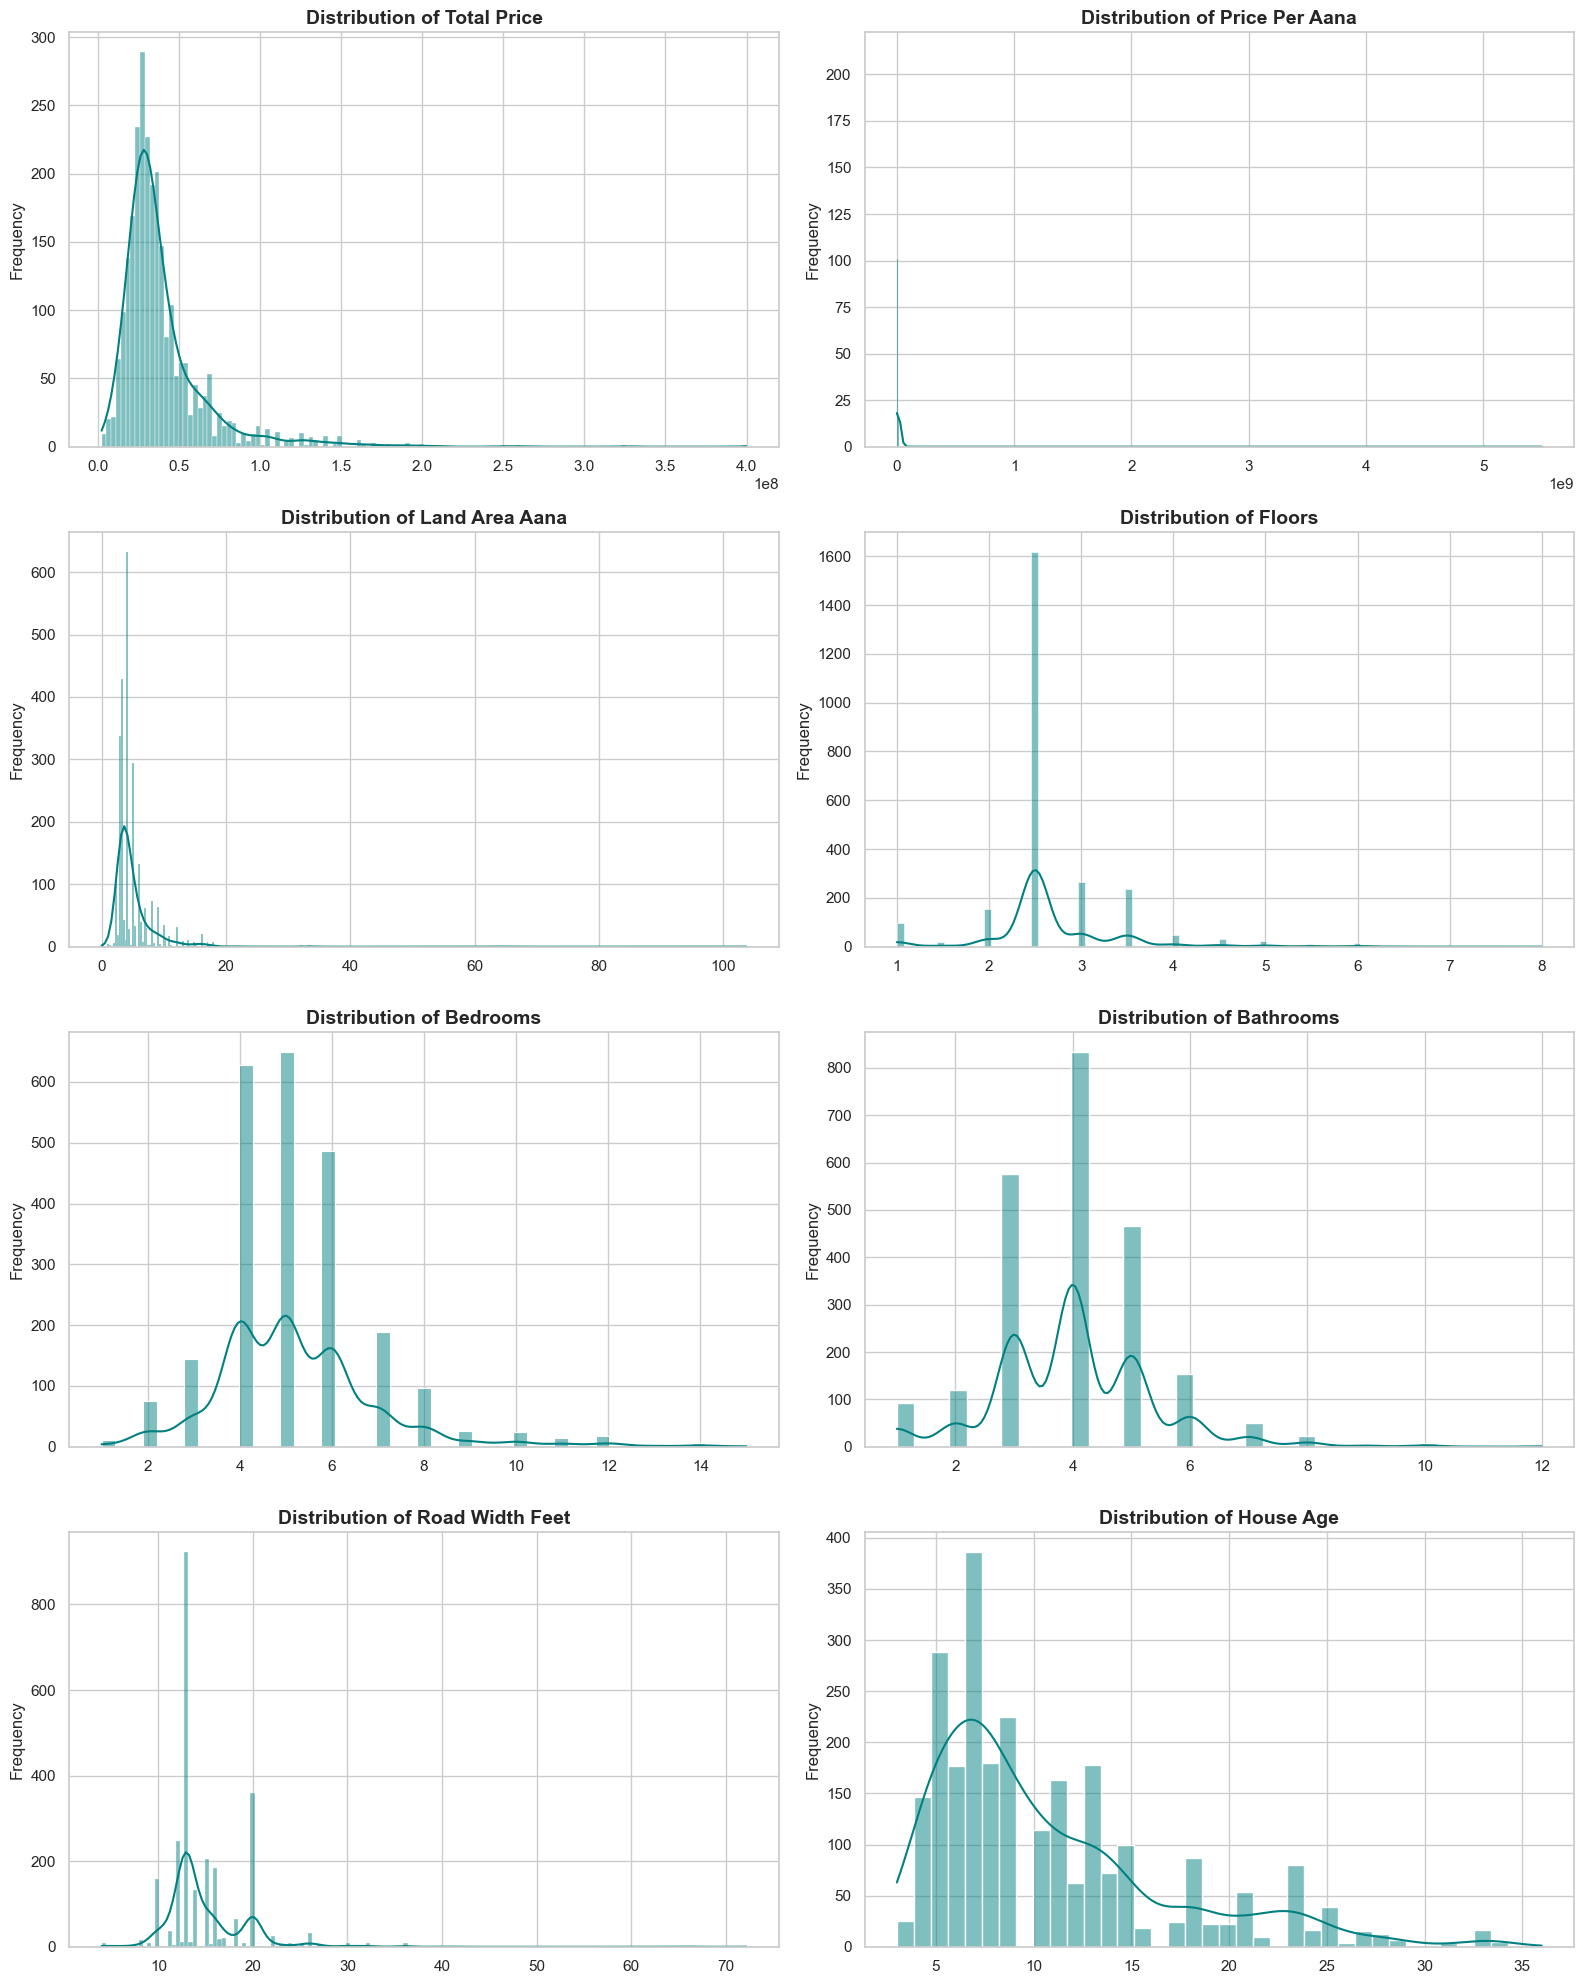

In [37]:


# 1. Define the numerical columns we want to see
num_cols = ['total_price', 'price_per_aana', 'land_area_aana', 'floors', 
            'bedrooms', 'bathrooms', 'road_width_feet', 'house_age']

# 2. Create a grid (4 rows, 2 columns)
# figsize (Width, Height) - Adjust height so it fits your screen comfortably
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20))
axes = axes.flatten() # Flatten 2D array of axes to 1D for easy looping

for i, col in enumerate(num_cols):
    # Plotting Histogram + KDE (Kernel Density Estimate)
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='teal')
    
    # Adding titles and making them readable
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

# 3. Use tight_layout to prevent titles from overlapping with charts
plt.tight_layout()
plt.show()

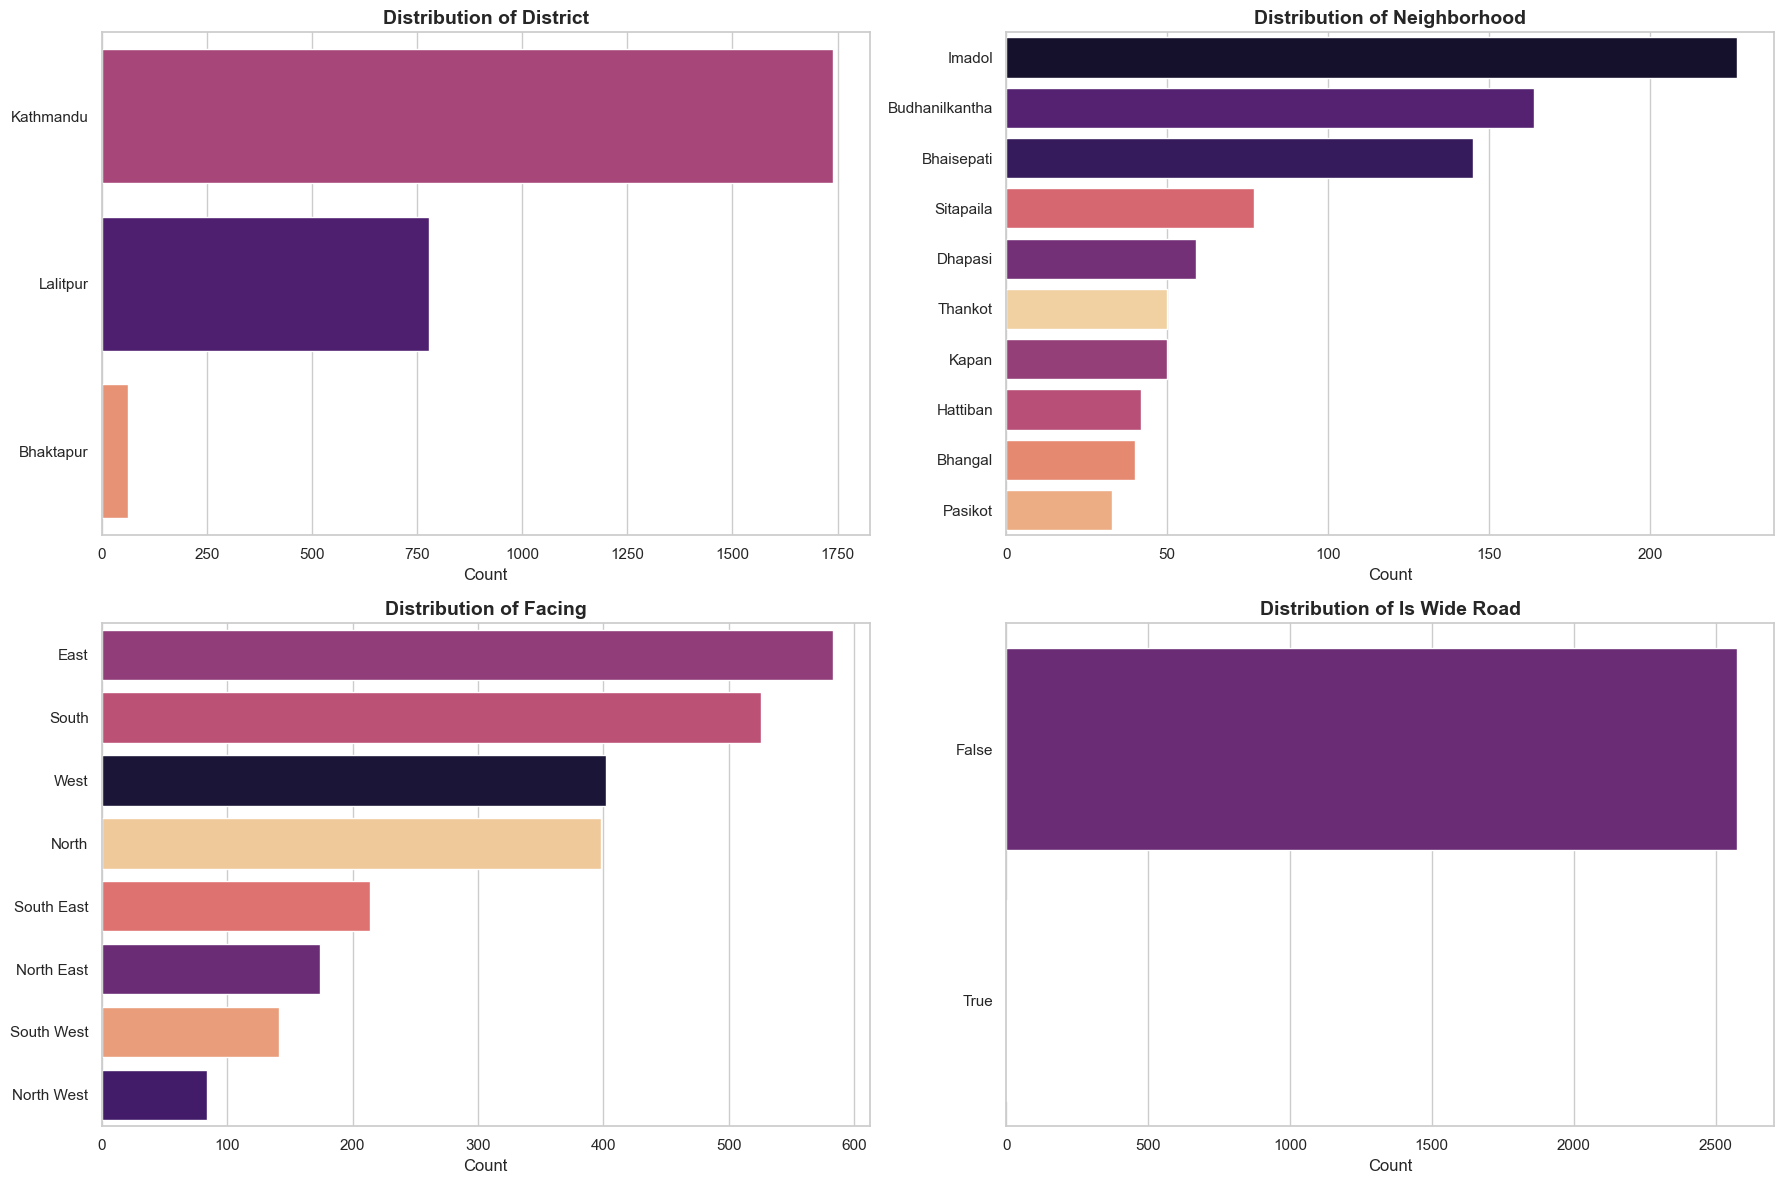

In [38]:
# 1. Updated list for House Data (df3) specifically
# Removed 'road_type' since it's not in your df3 index
cat_cols = ['district', 'neighborhood', 'facing', 'is_wide_road']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Get top 10 values
    top_values = df[col].value_counts().nlargest(10).index
    plot_data = df[df[col].isin(top_values)]
    
    # Updated Seaborn syntax to fix the FutureWarning:
    # 1. Assign col to 'hue'
    # 2. Set 'legend=False'
    sns.countplot(
        data=plot_data, 
        y=col, 
        ax=axes[i], 
        order=top_values, 
        hue=col,            # New: Explicitly assign hue
        palette='magma',
        legend=False        # New: Hide redundant legend
    )
    
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

# =============================================================================
# 📊 UNIVARIATE ANALYSIS — KEY CONCLUSIONS
# =============================================================================

# -----------------------------------------------------------------------------
# 🏙️ DISTRICT DISTRIBUTION
# -----------------------------------------------------------------------------
# - Kathmandu has the most listings (~1,750), followed by Lalitpur (~750)
# - Bhaktapur and Unknown districts have very few listings
# - This means our dataset is heavily Kathmandu-focused
# - Our price prediction model may perform better for Kathmandu than other districts
# - Conclusion: Dataset is geographically imbalanced — Kathmandu dominant

# -----------------------------------------------------------------------------
# 🏘️ NEIGHBORHOOD DISTRIBUTION
# -----------------------------------------------------------------------------
# - Imadol is the most listed neighborhood (~210 listings)
# - Followed by Budhanilkantha and Bhaisepati
# - Top 10 neighborhoods have counts between 50–210 (reasonably balanced)
# - Conclusion: No single neighborhood is overwhelmingly dominant, which is healthy
#   for building a location-based pricing model

# -----------------------------------------------------------------------------
# 🧭 FACING DISTRIBUTION
# -----------------------------------------------------------------------------
# - East and South facing properties are the most common (~580–600 each)
# - North-West is the least common (~120)
# - This reflects Nepali cultural preference — East/South facing is considered
#   auspicious (Vastu Shastra) and gets better sunlight
# - Conclusion: Facing direction is a culturally significant feature and likely
#   has a strong influence on property price

# -----------------------------------------------------------------------------
# 🛣️ IS WIDE ROAD DISTRIBUTION
# -----------------------------------------------------------------------------
# - Vast majority of properties (~2,500) are on narrow roads (False)
# - Very few properties are on wide roads (True)
# - This is a heavily imbalanced binary feature
# - Conclusion: Wide road access is rare but likely commands a significant
#   price premium — must be handled carefully in ML (do not treat as balanced)

# -----------------------------------------------------------------------------
# 💰 TOTAL PRICE DISTRIBUTION
# -----------------------------------------------------------------------------
# - Distribution is heavily right-skewed (long tail on the right)
# - Most properties are priced between 0 – 5 Crore NPR
# - A few properties go up to 40 Crore NPR (outliers)
# - Conclusion: Price data is NOT normally distributed
#   → We MUST apply log transformation (np.log1p) before feeding into ML models
#   → Without this, outliers will dominate and hurt model accuracy

# -----------------------------------------------------------------------------
# 💵 PRICE PER AANA DISTRIBUTION
# -----------------------------------------------------------------------------
# - Also heavily right-skewed, similar to total price
# - Most values are between 0 – 1 Crore per aana
# - Long tail extends up to 5 Crore per aana (luxury/commercial plots)
# - Conclusion: Same as total price — log transformation required before modeling
#   This column will be very useful for comparing land value across locations

# -----------------------------------------------------------------------------
# 🌿 LAND AREA (AANA) DISTRIBUTION
# -----------------------------------------------------------------------------
# - Most properties are between 2–10 aana (small residential plots)
# - Peak is around 3–5 aana which is typical for Kathmandu valley homes
# - Long tail up to ~100 aana represents large/commercial plots
# - Conclusion: Majority of listings are standard residential-sized plots
#   Outliers above 40 aana are likely commercial properties or ropani-scale land

# -----------------------------------------------------------------------------
# 🏢 FLOORS DISTRIBUTION
# -----------------------------------------------------------------------------
# - Strong peaks at 2.5 and 3 floors — most common in Nepal
# - Half-floor values (1.5, 2.5, 3.5) are NOT errors — they represent
#   properties with a partial/incomplete top floor, which is very common in Nepal
# - Conclusion: Floor data is clean and realistic
#   Nepali construction style explains the half-floor pattern clearly

# -----------------------------------------------------------------------------
# 🛏️ BEDROOMS DISTRIBUTION
# -----------------------------------------------------------------------------
# - Most common bedroom counts are 4, 5, and 6
# - Peak is at 4–5 bedrooms, typical for Nepali family homes
# - Small number of properties with 10–15 bedrooms likely represent
#   guest houses or commercial buildings, not regular homes
# - Conclusion: Bedroom count is a strong pricing feature
#   Outliers (>10 bedrooms) should be treated as a separate property category

# -----------------------------------------------------------------------------
# 🚿 BATHROOMS DISTRIBUTION
# -----------------------------------------------------------------------------
# - Most common values are 3 and 4 bathrooms — closely follows bedroom count
# - Clear peaks which makes logical sense (more bedrooms = more bathrooms)
# - Values above 10 are likely the same large commercial/guesthouse properties
# - Conclusion: Bathrooms and bedrooms are highly correlated features
#   Both are strong predictors of property price

# -----------------------------------------------------------------------------
# 🛣️ ROAD WIDTH (FEET) DISTRIBUTION
# -----------------------------------------------------------------------------
# - Three distinct peaks at 10 ft, 13 ft, and 20 ft
# - These match Nepal's standard road categories:
#     → 10 ft = narrow lane (galli)
#     → 13 ft = standard residential road
#     → 20 ft = wide/main road
# - Conclusion: Road width data is clean and validates our cleaning was correct
#   Wide roads (20ft+) are associated with higher property prices
#   The few values near 60–80 ft are likely main highways or commercial areas

# -----------------------------------------------------------------------------
# 🏚️ HOUSE AGE DISTRIBUTION
# -----------------------------------------------------------------------------
# - Peak is at 5–10 years old — most listed properties are relatively new
# - Gradually decreases toward 30–35 years
# - Makes sense: newer properties are more actively listed for sale
# - Conclusion: Most properties in our dataset were built between 2014–2019 AD
#   Older properties (>25 years) are rare but valid — not data errors
#   House age is likely negatively correlated with price (newer = more expensive)

# =============================================================================
# 🔑 OVERALL CONCLUSIONS FOR THE TEACHER
# =============================================================================
# 1. Price columns are RIGHT-SKEWED → Log transformation needed before ML
# 2. Dataset is KATHMANDU-DOMINANT → Model may be biased toward Kathmandu prices
# 3. Floors with .5 values are VALID → Nepali construction style, not errors
# 4. Road width peaks at 10/13/20 ft → VALIDATES our data cleaning
# 5. East/South facing properties dominate → Cultural preference confirmed in data
# 6. Most properties are 3–6 bedrooms, 2–5 aana → Typical Nepali family home profile
# 7. Is_Wide_Road is IMBALANCED → Needs special handling in ML models
# =============================================================================

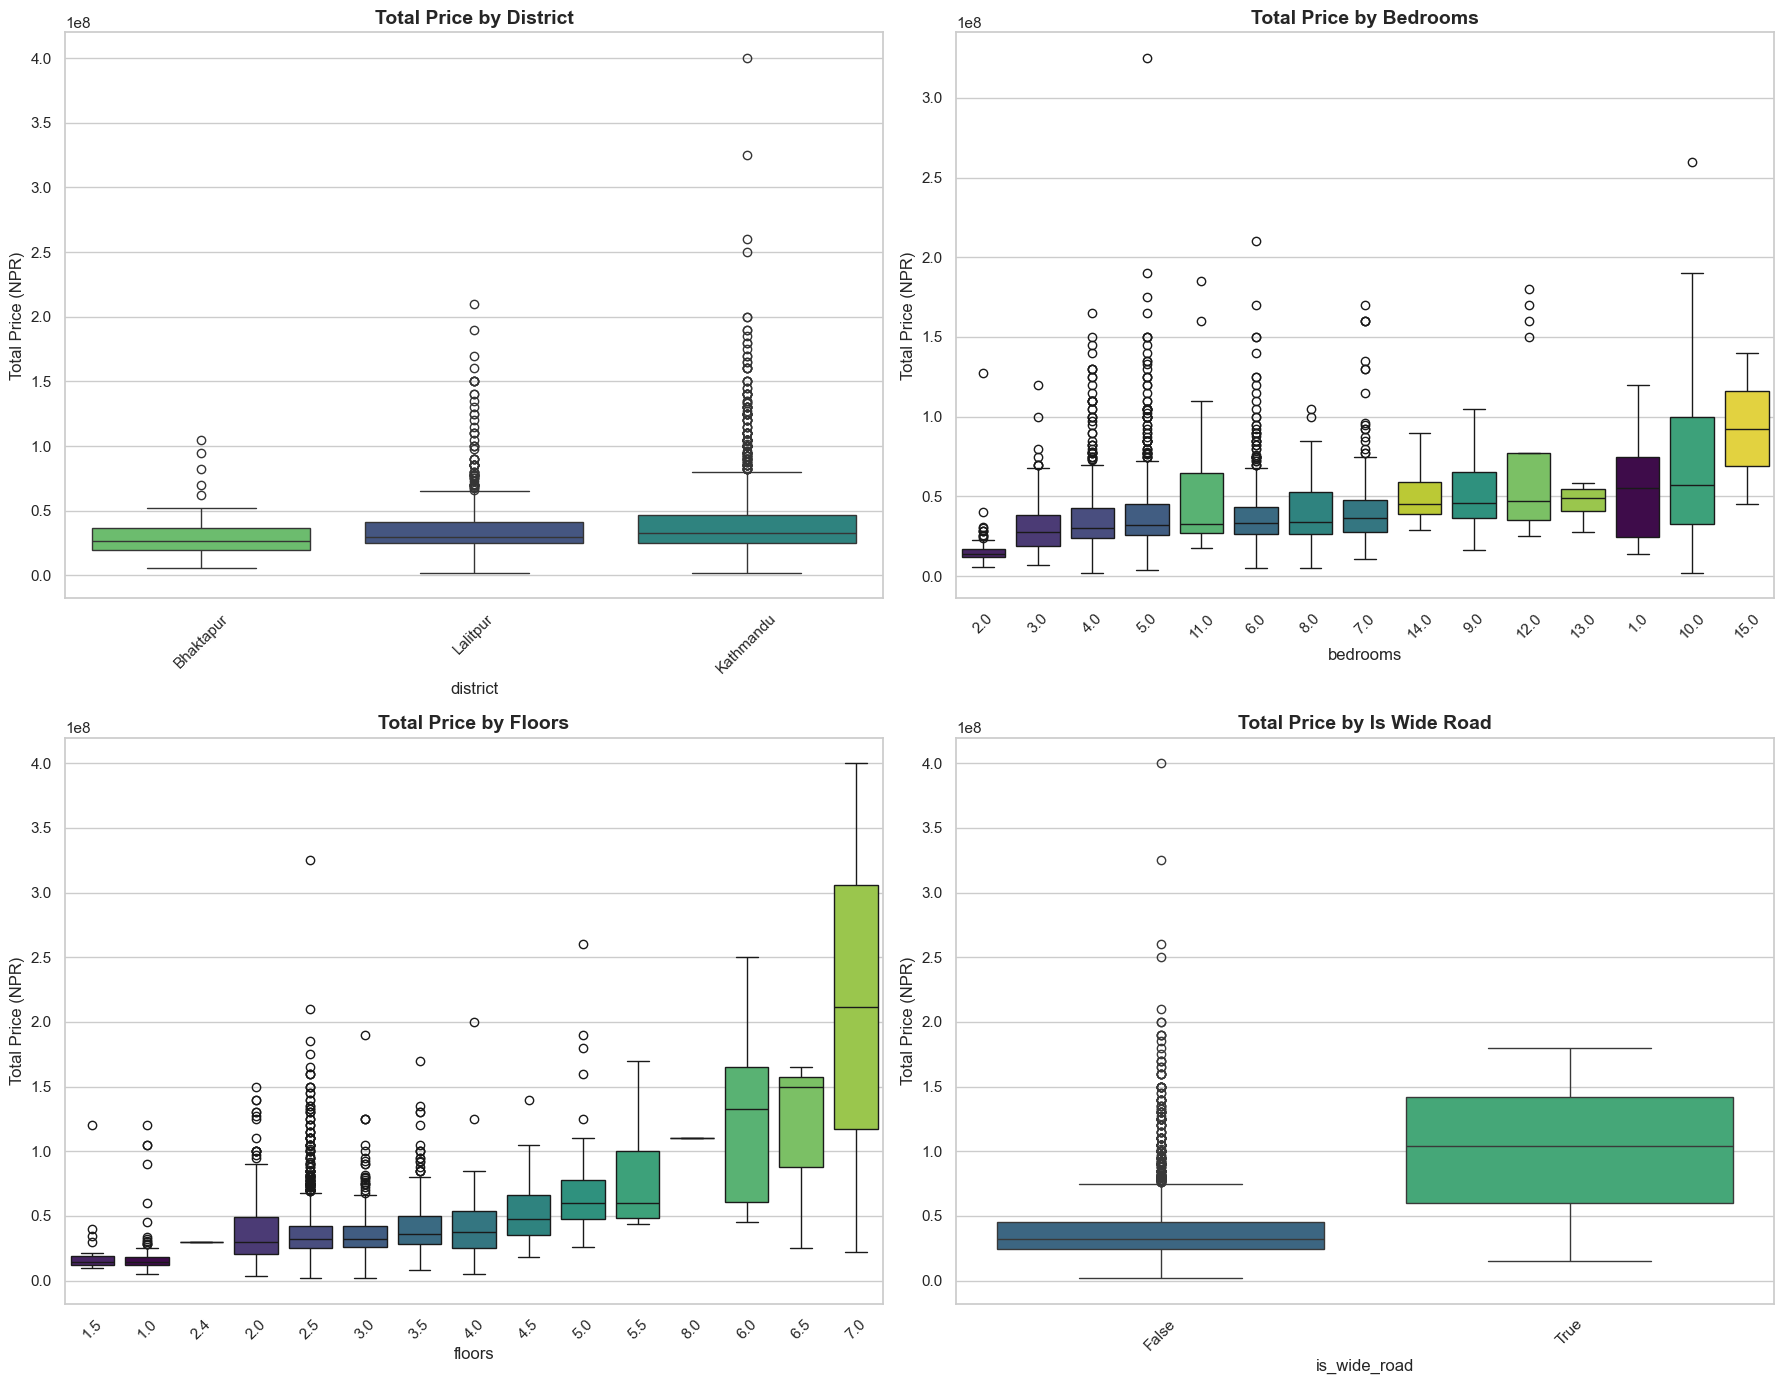

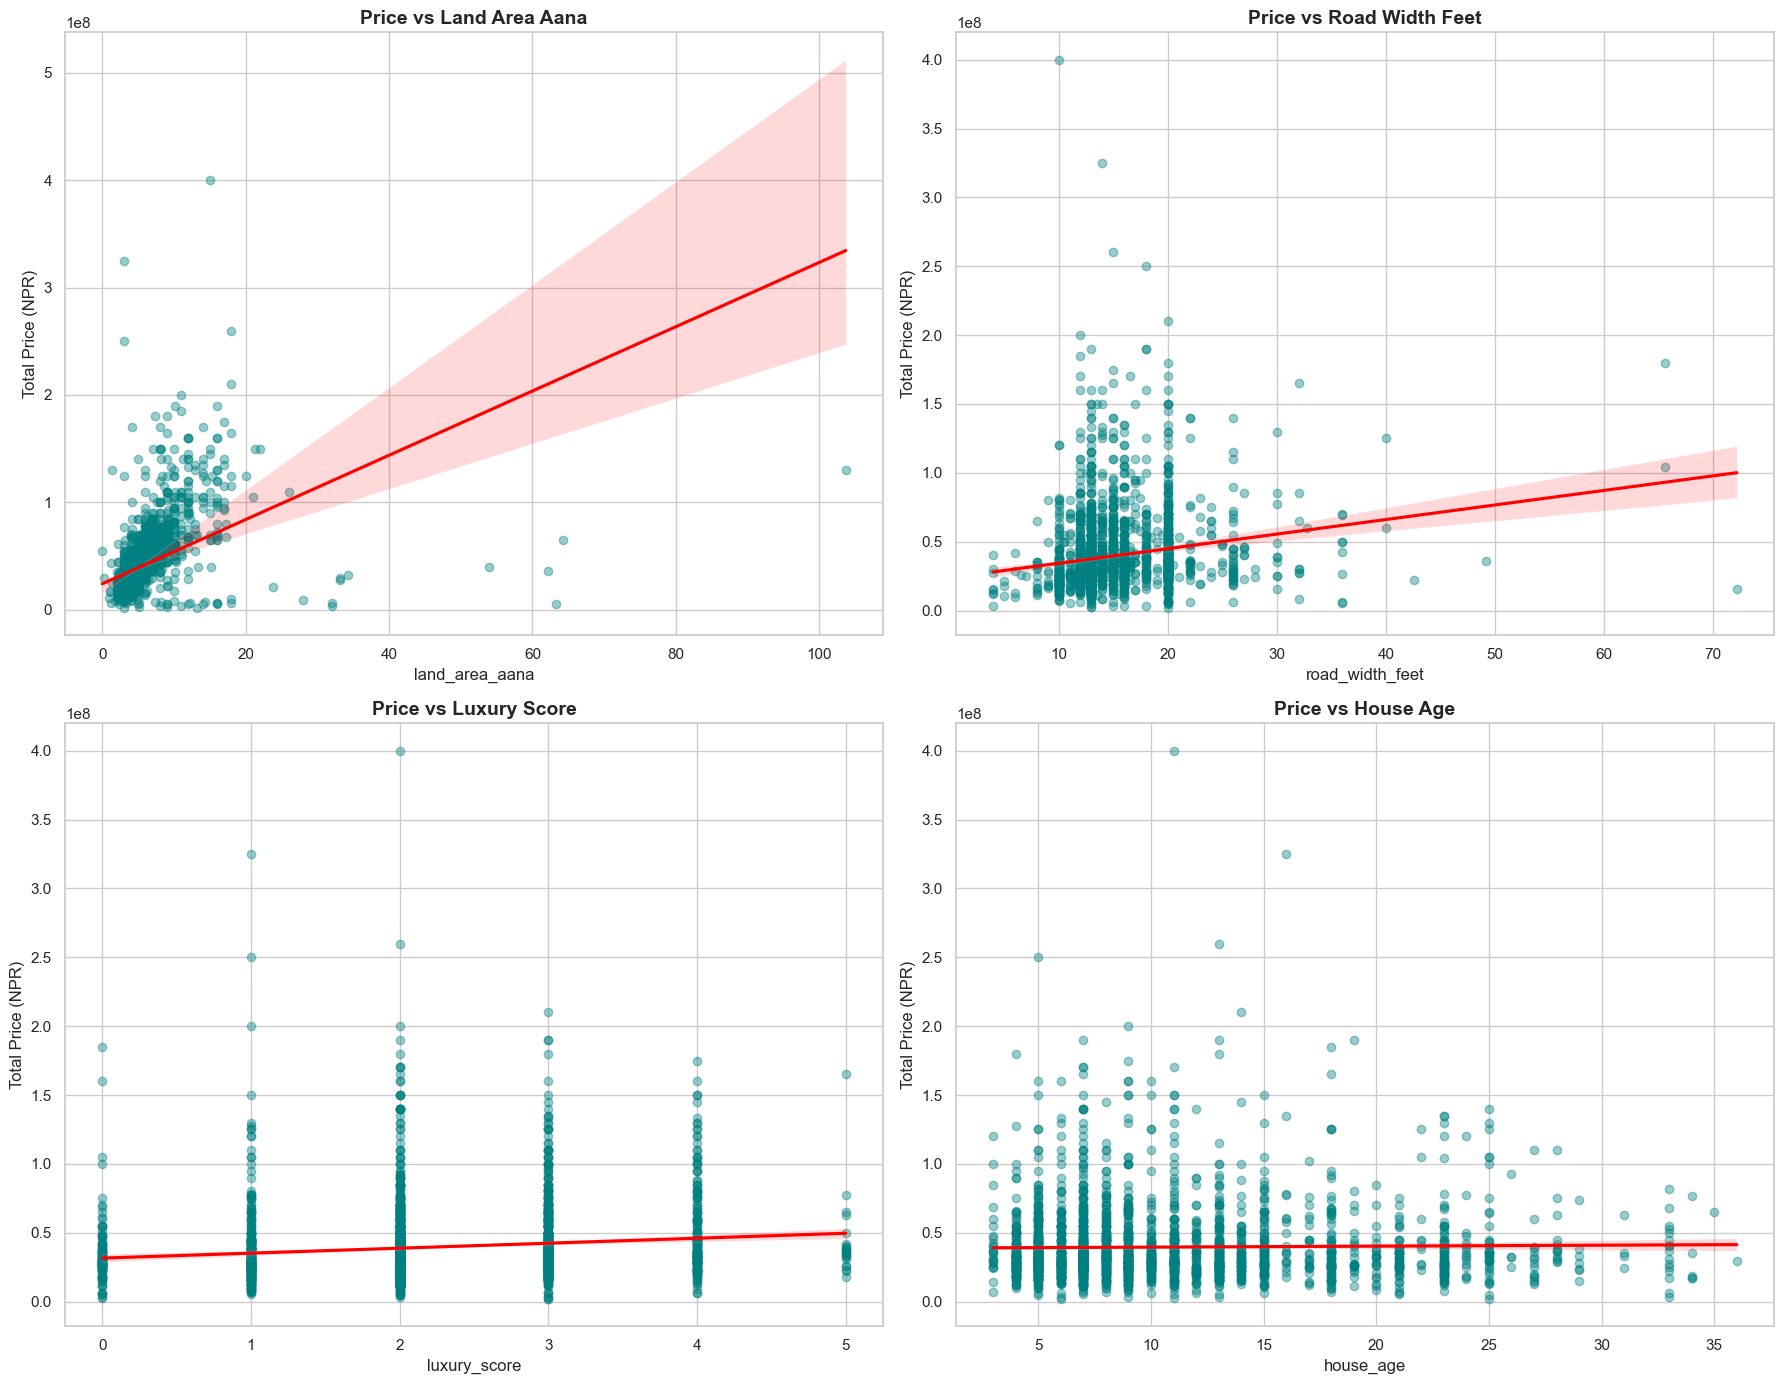

In [39]:


# 1. PRICE VS CATEGORIES (Box Plots)
# We use Box Plots to see which category typically costs more
cat_bivariate = ['district', 'bedrooms', 'floors', 'is_wide_road']

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_bivariate):
    # Sorting by median price makes the chart much easier to interpret
    order = df.groupby(col)['total_price'].median().sort_values().index
    
    sns.boxplot(data=df, x=col, y='total_price', ax=axes[i], order=order, palette='viridis', hue=col, legend=False)
    axes[i].set_title(f'Total Price by {col.replace("_", " ").title()}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Total Price (NPR)')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 2. PRICE VS CONTINUOUS NUMBERS (Scatter Plots)
# We use Scatter Plots to see if the relationship is linear
num_bivariate = ['land_area_aana', 'road_width_feet', 'luxury_score', 'house_age']

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(num_bivariate):
    # regplot adds a regression line to show the trend
    sns.regplot(data=df, x=col, y='total_price', ax=axes[i], 
                scatter_kws={'alpha':0.4, 'color':'teal'}, line_kws={'color':'red'})
    
    axes[i].set_title(f'Price vs {col.replace("_", " ").title()}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Total Price (NPR)')

plt.tight_layout()
plt.show()

# =============================================================================
# 📊 BIVARIATE ANALYSIS — KEY CONCLUSIONS
# =============================================================================

# -----------------------------------------------------------------------------
# IMAGE 1 — BOX PLOTS
# -----------------------------------------------------------------------------

# PRICE BY DISTRICT:
# - Kathmandu has the most outliers (extreme high-value properties)
# - Lalitpur shows slightly higher median than others
# → District alone is not a strong price differentiator at median level,
#   but Kathmandu clearly has more luxury/high-end properties

# PRICE BY BEDROOMS:
# - General upward trend: more bedrooms = higher price (as expected)
# - 2–5 bedrooms are tightly clustered at lower prices (standard homes)
# - 10–16 bedrooms show much higher and wider price ranges (guesthouses/commercial)
# - High variance in all bedroom categories — bedrooms alone can't predict price
# → Bedroom count is a useful but not sufficient feature for price prediction

# PRICE BY FLOORS:
# - Clear positive trend: more floors = significantly higher price
# - 1–2.5 floors are low priced and tightly clustered
# - 6–7 floors show dramatically higher median and very wide spread
# - Strongest visual trend among all box plots
# → Floors is one of the STRONGEST categorical predictors of price in this dataset

# PRICE BY IS WIDE ROAD:
# - Wide road (True) properties have a MUCH higher median price (~1 Crore+)
#   compared to narrow road (False) properties (~0.4 Crore)
# - Wide road also shows larger spread (more variation in price)
# → Wide road access is a significant price driver despite being rare in the dataset

# -----------------------------------------------------------------------------
# IMAGE 2 — SCATTER PLOTS
# -----------------------------------------------------------------------------

# PRICE vs LAND AREA (AANA):
# - Clear positive correlation — larger land = higher price
# - Regression line shows a steady upward trend with wide confidence interval
# - Most data is clustered below 20 aana, prices mostly under 1 Crore
# - Outliers above 40 aana show very high price variation
# → Land area is the STRONGEST numerical predictor of total price

# PRICE vs ROAD WIDTH (FEET):
# - Weak positive correlation — wider road slightly increases price
# - Data is heavily clustered at 10–20 ft (standard road widths)
# - Wide confidence interval means the relationship is inconsistent
# → Road width has some influence on price but is not a reliable standalone predictor

# PRICE vs LUXURY SCORE:
# - Regression line is almost completely FLAT — nearly zero correlation
# - Data forms vertical clusters at integer scores (0,1,2,3,4,5)
# - Price spread is similar across all luxury score values
# → Luxury score as currently defined does NOT correlate with price
#   → Consider redefining this feature or dropping it from the ML model

# PRICE vs HOUSE AGE:
# - Regression line is nearly flat with a very slight downward trend
# - Prices are spread randomly across all age groups
# - No clear pattern — older houses do not consistently cost less
# → House age has very weak negative correlation with price
#   → May not be a useful standalone feature, but could help when combined with location

# =============================================================================
# 🔑 OVERALL TAKEAWAYS
# =============================================================================
# 1. FLOORS and LAND AREA are the strongest predictors of price
# 2. WIDE ROAD ACCESS commands a significant price premium
# 3. LUXURY SCORE needs to be redefined — currently shows no correlation with price
# 4. HOUSE AGE and ROAD WIDTH have weak relationships with price individually
# 5. Most relationships have HIGH VARIANCE → a single feature cannot predict price well
#    → A combination of features (multi-variable model) will be needed
# =============================================================================

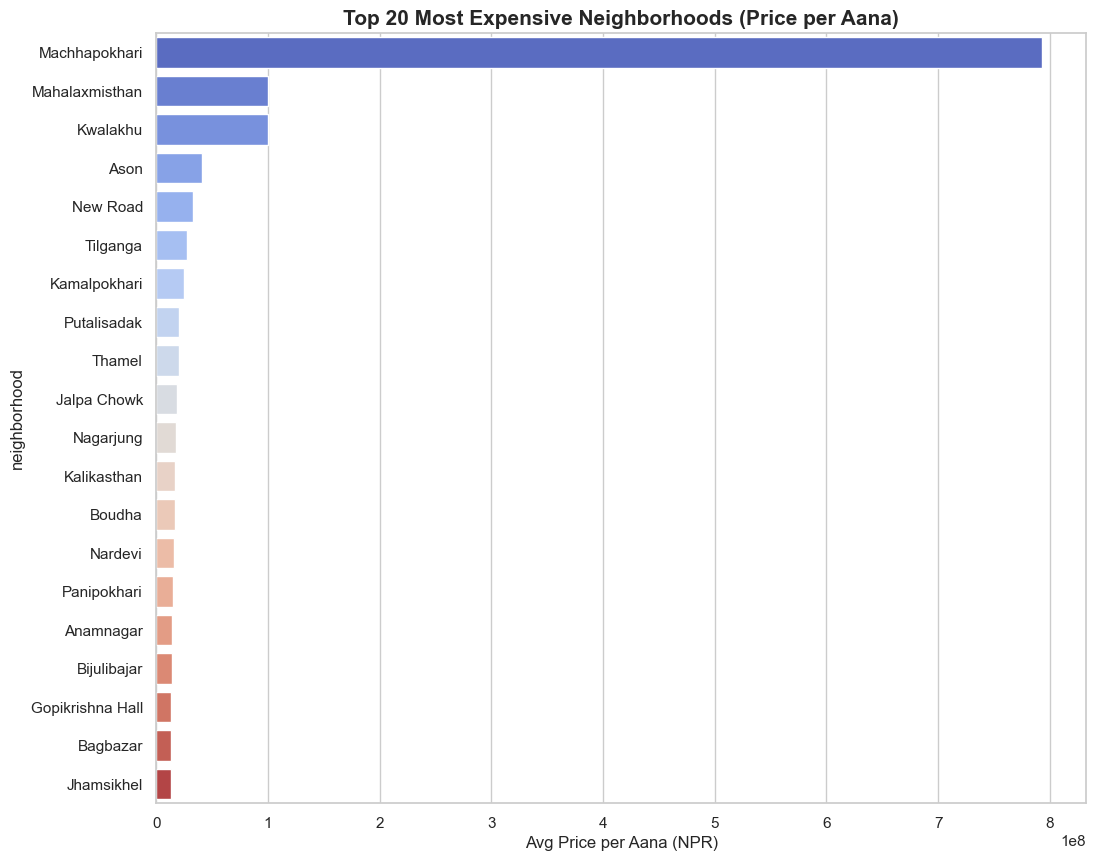

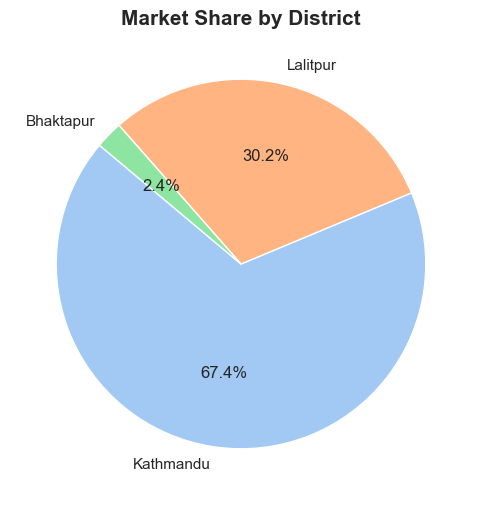

In [40]:
# --- GEOGRAPHIC DEEP DIVE ---

# 1. Top 20 Most Expensive Neighborhoods (by Mean Price per Aana)
plt.figure(figsize=(12, 10))
top_20_hoods = df.groupby('neighborhood')['price_per_aana'].mean().sort_values(ascending=False).head(20)

sns.barplot(x=top_20_hoods.values, y=top_20_hoods.index, palette='coolwarm', hue=top_20_hoods.index, legend=False)
plt.title('Top 20 Most Expensive Neighborhoods (Price per Aana)', fontsize=15, fontweight='bold')
plt.xlabel('Avg Price per Aana (NPR)')
plt.show()

# 2. Listing Density by District
plt.figure(figsize=(10, 6))
df['district'].value_counts().plot.pie(autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Market Share by District', fontsize=15, fontweight='bold')
plt.ylabel('')
plt.show()

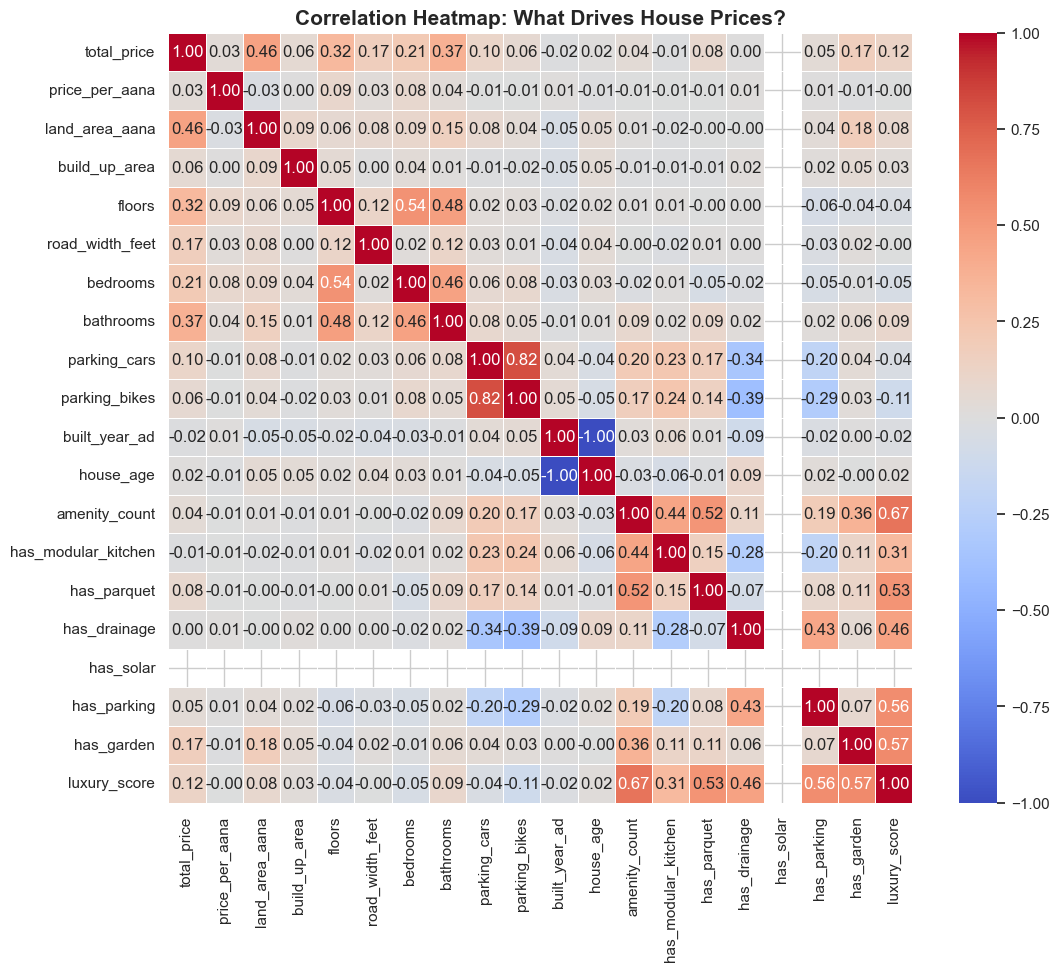

In [41]:
# Select only numerical columns for correlation
numerical_df = df.select_dtypes(include=['float64', 'int64', 'int32'])

# Calculate the correlation matrix
corr_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: What Drives House Prices?', fontsize=15, fontweight='bold')
plt.show()

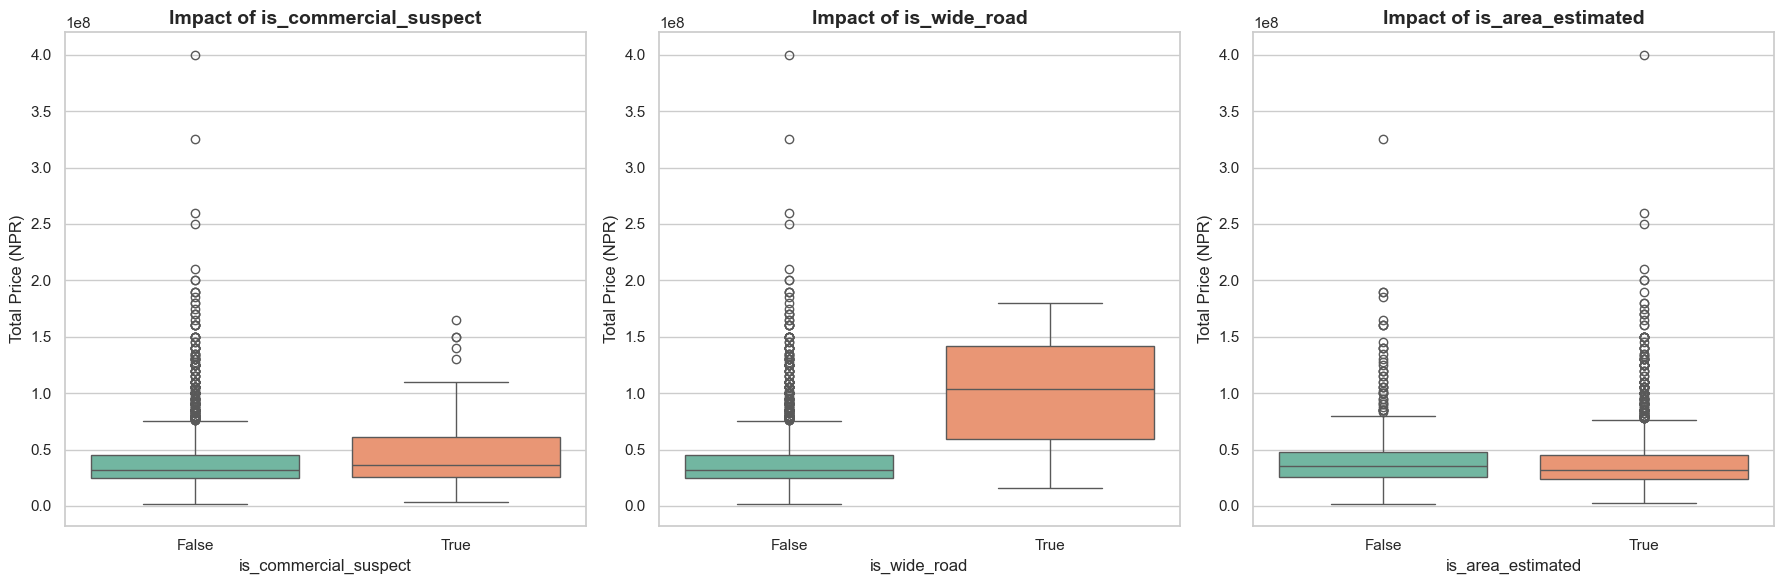


Median Price for is_commercial_suspect:
is_commercial_suspect
False    32000000.0
True     36000000.0
Name: total_price, dtype: float64

Median Price for is_wide_road:
is_wide_road
False     32000000.0
True     104000000.0
Name: total_price, dtype: float64

Median Price for is_area_estimated:
is_area_estimated
False    35000000.0
True     31500000.0
Name: total_price, dtype: float64


In [42]:
# --- FLAG COLUMN ANALYSIS ---

flags = ['is_commercial_suspect', 'is_wide_road', 'is_area_estimated']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(flags):
    # Comparing price distributions for True vs False
    sns.boxplot(data=df, x=col, y='total_price', ax=axes[i], palette='Set2', hue=col, legend=False)
    axes[i].set_title(f'Impact of {col}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Total Price (NPR)')

plt.tight_layout()
plt.show()

# Quick calculation of the "Premium" for these flags
for col in flags:
    premium = df.groupby(col)['total_price'].median()
    print(f"\nMedian Price for {col}:")
    print(premium)

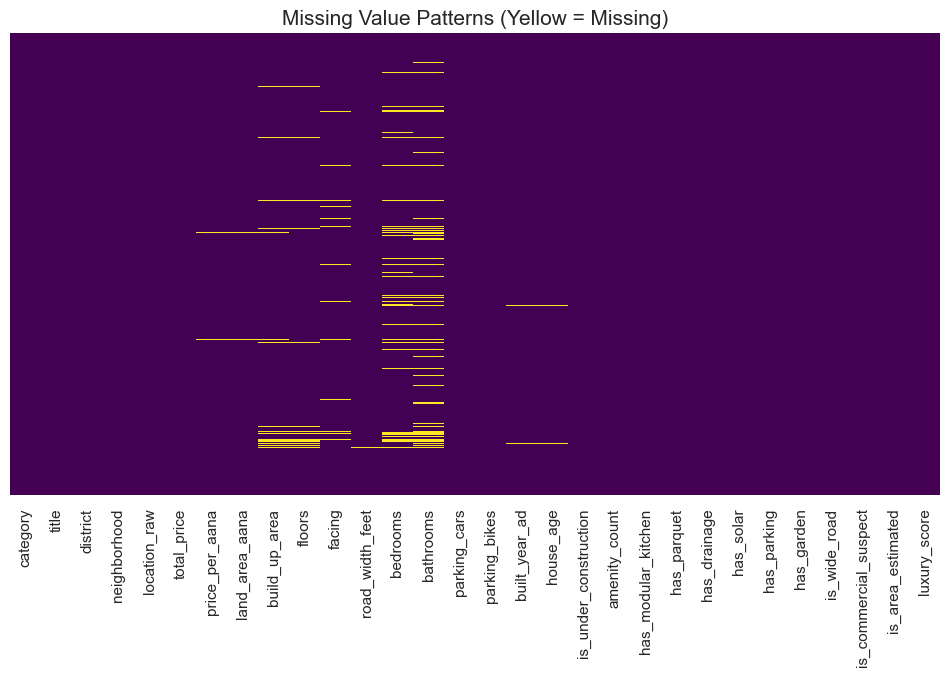

Missing values per column:
bathrooms          252
bedrooms           204
facing              58
build_up_area       57
floors              49
built_year_ad       25
house_age           25
price_per_aana      16
land_area_aana      16
road_width_feet     12
dtype: int64


In [44]:
# --- MISSING VALUE HEATMAP ---
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Value Patterns (Yellow = Missing)', fontsize=15)
plt.show()

# Print the exact counts
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

# =============================================================================
# 📊 MISSING VALUE PATTERN ANALYSIS — KEY CONCLUSIONS
# =============================================================================

# -----------------------------------------------------------------------------
# COLUMNS WITH NO MISSING VALUES (completely clean ✅)
# -----------------------------------------------------------------------------
# - category, title, district, neighborhood, location_raw, total_price
# - all has_* binary columns (has_modular_kitchen, has_parquet, has_drainage,
#   has_solar, has_parking, has_garden)
# - is_wide_road, is_commercial_suspect, is_area_estimated, luxury_score
# - amenity_count, is_under_construction
# → These columns are ready to use directly in ML — no imputation needed

# -----------------------------------------------------------------------------
# COLUMNS WITH MODERATE MISSING VALUES (needs attention ⚠️)
# -----------------------------------------------------------------------------
# - price_per_aana  → Some missing, likely where land area was unknown
# - land_area_aana  → Missing in some rows — important feature, needs imputation
# - floors          → Small number of missing — impute with median (2.5 or 3)
# - facing          → Some missing — impute with mode (East, most common)
# - road_width_feet → Some missing — impute with median (13 ft)
# - bedrooms        → Moderate missing — impute with median (4 or 5)
# - bathrooms       → Moderate missing — impute with median (3 or 4)
# - built_year_ad   → Small missing — impute with median year
# - house_age       → Same rows as built_year_ad (they are linked)

# -----------------------------------------------------------------------------
# COLUMNS WITH HIGH MISSING VALUES (handle carefully 🔴)
# -----------------------------------------------------------------------------
# - build_up_area   → MOST missing of all columns (very long yellow lines)
#                     Over 75% of rows are missing this value
#                     → Do NOT impute — too much missing data will introduce bias
#                     → Either drop this column or use it only where available
# - parking_cars    → High missing — most properties didn't report parking details
# - parking_bikes   → Same pattern as parking_cars (they go missing together)
#                     → Replace missing with 0 (assume no parking reported = no parking)

# -----------------------------------------------------------------------------
# PATTERN OBSERVATIONS
# -----------------------------------------------------------------------------
# - Missing values in bedrooms, bathrooms, floors, facing tend to occur
#   IN THE SAME ROWS → same listings had incomplete data entry
# - parking_cars and parking_bikes always go missing together → same source issue
# - build_up_area missingness is INDEPENDENT — different listings skip it entirely
# → This suggests TWO types of missing data:
#     1. Random missing (data entry oversight) → safe to impute with median/mode
#     2. Structural missing (build_up_area) → column was often not collected at all

# =============================================================================
# 🔑 OVERALL TAKEAWAYS — WHAT TO DO BEFORE ML
# =============================================================================
# 1. DROP build_up_area → too many missing values (75%+) to impute reliably
# 2. IMPUTE with MEDIAN: land_area_aana, floors, road_width_feet, bedrooms,
#                        bathrooms, built_year_ad, house_age
# 3. IMPUTE with MODE:   facing (most common = East)
# 4. FILL WITH 0:        parking_cars, parking_bikes (no report = no parking)
# 5. NO ACTION NEEDED:   binary columns, district, neighborhood, price, amenity_count
# =============================================================================

In [45]:
df.sample()

,category,title,district,neighborhood,location_raw,total_price,price_per_aana,land_area_aana,build_up_area,floors,facing,road_width_feet,bedrooms,bathrooms,parking_cars,parking_bikes,built_year_ad,house_age,is_under_construction,amenity_count,has_modular_kitchen,has_parquet,has_drainage,has_solar,has_parking,has_garden,is_wide_road,is_commercial_suspect,is_area_estimated,luxury_score
2367,house,"House on sale at Thapathali, Kathmandu",Kathmandu,Thapathali,"Thapathali, Kathmandu",69000000.0,6900000.0,10.0,5989.38,2.5,West,18.0,4.0,4.0,0.0,0.0,2017.0,9.0,False,0,0,0,0,0,0,0,False,False,True,0


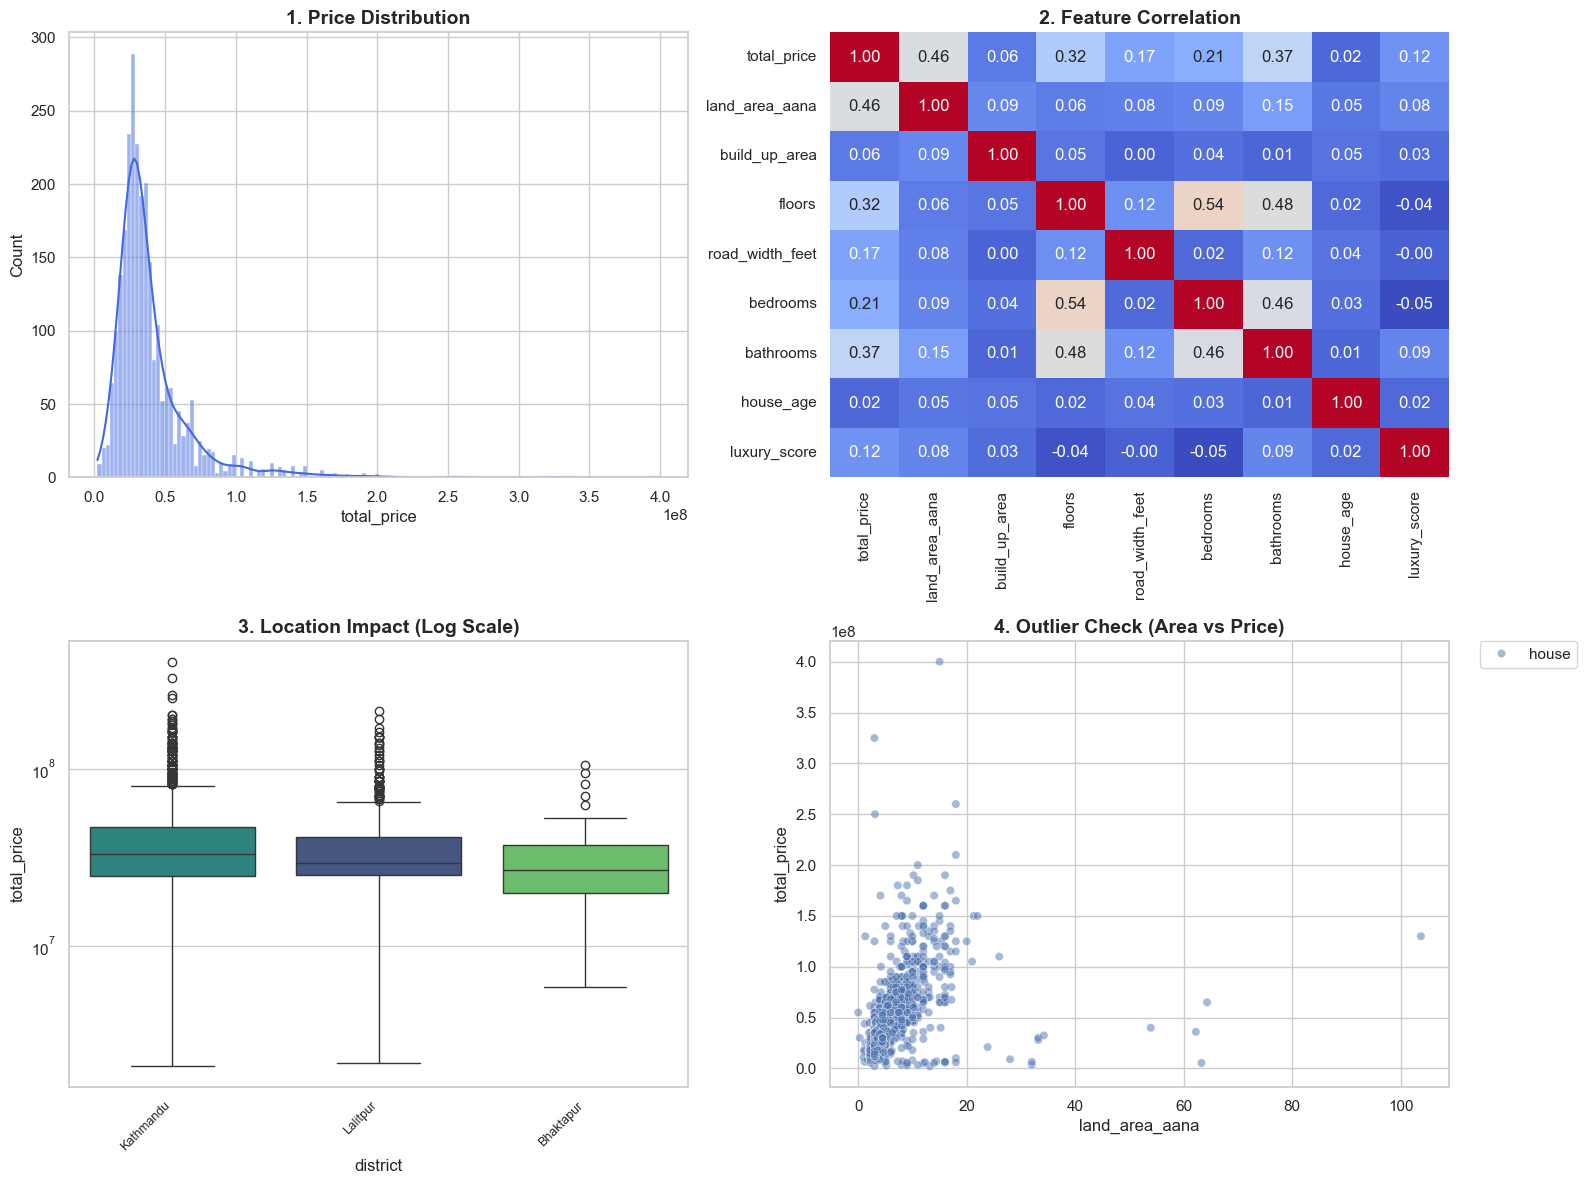

In [52]:

# Set theme for a clean look
sns.set_theme(style="whitegrid")

# Define the figure and a 2x2 grid in one single container
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. TOP-LEFT: Price Distribution (Check for Skewness)
sns.histplot(data=df, x='total_price', kde=True, color='royalblue', ax=axes[0, 0])
axes[0, 0].set_title('1. Price Distribution', fontsize=14, fontweight='bold')

# 2. TOP-RIGHT: Correlation Heatmap
cols_to_corr = ['total_price', 'land_area_aana', 'build_up_area', 'floors', 
                'road_width_feet', 'bedrooms', 'bathrooms', 'house_age', 'luxury_score']
existing_cols = [c for c in cols_to_corr if c in df.columns]
sns.heatmap(df[existing_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0, 1], cbar=False)
axes[0, 1].set_title('2. Feature Correlation', fontsize=14, fontweight='bold')

# 3. BOTTOM-LEFT: District vs Price
order = df.groupby('district')['total_price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='district', y='total_price', order=order, hue='district', 
            palette='viridis', legend=False, ax=axes[1, 0])
axes[1, 0].set_yscale('log')
axes[1, 0].set_xticks(range(len(order)))
axes[1, 0].set_xticklabels(order, rotation=45, ha='right', fontsize=9)
axes[1, 0].set_title('3. Location Impact (Log Scale)', fontsize=14, fontweight='bold')

# 4. BOTTOM-RIGHT: Area vs Price
sns.scatterplot(data=df, x='land_area_aana', y='total_price', hue='category', alpha=0.5, ax=axes[1, 1])
axes[1, 1].set_title('4. Outlier Check (Area vs Price)', fontsize=14, fontweight='bold')
axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# CRITICAL: Adjust layout to prevent overlap and force single-frame output
plt.tight_layout()
plt.show()

# =============================================================================
# 📊 EDA SUMMARY DASHBOARD — KEY CONCLUSIONS
# =============================================================================

# -----------------------------------------------------------------------------
# 1. PRICE DISTRIBUTION
# -----------------------------------------------------------------------------
# - Heavily right-skewed — majority of properties priced under 0.5 Crore NPR
# - Peak is around 0.2–0.3 Crore, long tail extends to 4 Crore
# - Very few properties above 1.5 Crore (luxury segment is small)
# → Log transformation is MANDATORY before ML modeling
# → Most properties in dataset are mid-range residential homes

# -----------------------------------------------------------------------------
# 2. FEATURE CORRELATION (with total_price)
# -----------------------------------------------------------------------------
# - land_area_aana (0.46) → Strongest predictor of price
# - bathrooms      (0.37) → Second strongest — reflects overall house size
# - floors         (0.32) → More floors = more value
# - bedrooms       (0.21) → Moderate influence
# - road_width     (0.17) → Weak but present
# - house_age      (0.02) → Almost zero — age doesn't drive price
# - luxury_score   (0.12) → Very weak — needs redesigning
# Internal: floors↔bedrooms (0.54), bedrooms↔bathrooms (0.46) — multicollinearity present
# → Top features for ML: land_area, bathrooms, floors, bedrooms, road_width

# -----------------------------------------------------------------------------
# 3. LOCATION IMPACT (Log Scale)
# -----------------------------------------------------------------------------
# - All 3 districts have very similar median prices (boxes overlap significantly)
# - Kathmandu has the widest range and most outliers at the top
# - Lalitpur median is slightly lower than Kathmandu
# - Bhaktapur has the narrowest range — most consistently priced
# - Log scale reveals that even the cheapest properties across districts
#   are similarly priced (whiskers bottom out at same level ~10M NPR)
# → District is NOT a strong price differentiator at median level
# → But Kathmandu has significantly more high-value outliers (luxury market)

# -----------------------------------------------------------------------------
# 4. OUTLIER CHECK (Land Area vs Price)
# -----------------------------------------------------------------------------
# - Most data is tightly clustered below 20 aana and under 1.5M NPR
# - Clear positive trend: larger land = higher price
# - Several extreme outliers visible:
#     → High price, low area: likely premium location (Thamel, city center)
#     → High area, low price: likely outskirts or underdeveloped land
#     → One point near 100 aana is clearly an outlier — large commercial plot
# → Outliers should be treated carefully — do not remove blindly
#   as they may represent legitimate luxury or commercial properties

# =============================================================================
# 🔑 OVERALL TAKEAWAYS
# =============================================================================
# 1. Price is RIGHT-SKEWED → always use log scale for modeling and visualization
# 2. LAND AREA is the single most important feature driving price
# 3. DISTRICT has similar medians but Kathmandu dominates the luxury segment
# 4. BATHROOMS + FLOORS + BEDROOMS together capture house size well
# 5. OUTLIERS exist but are real listings — flag them, don't blindly drop them
# 6. No single feature predicts price perfectly → multi-feature ML model needed
# =============================================================================

C:\Users\DELL\AppData\Local\Temp\ipykernel_10352\4221260473.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


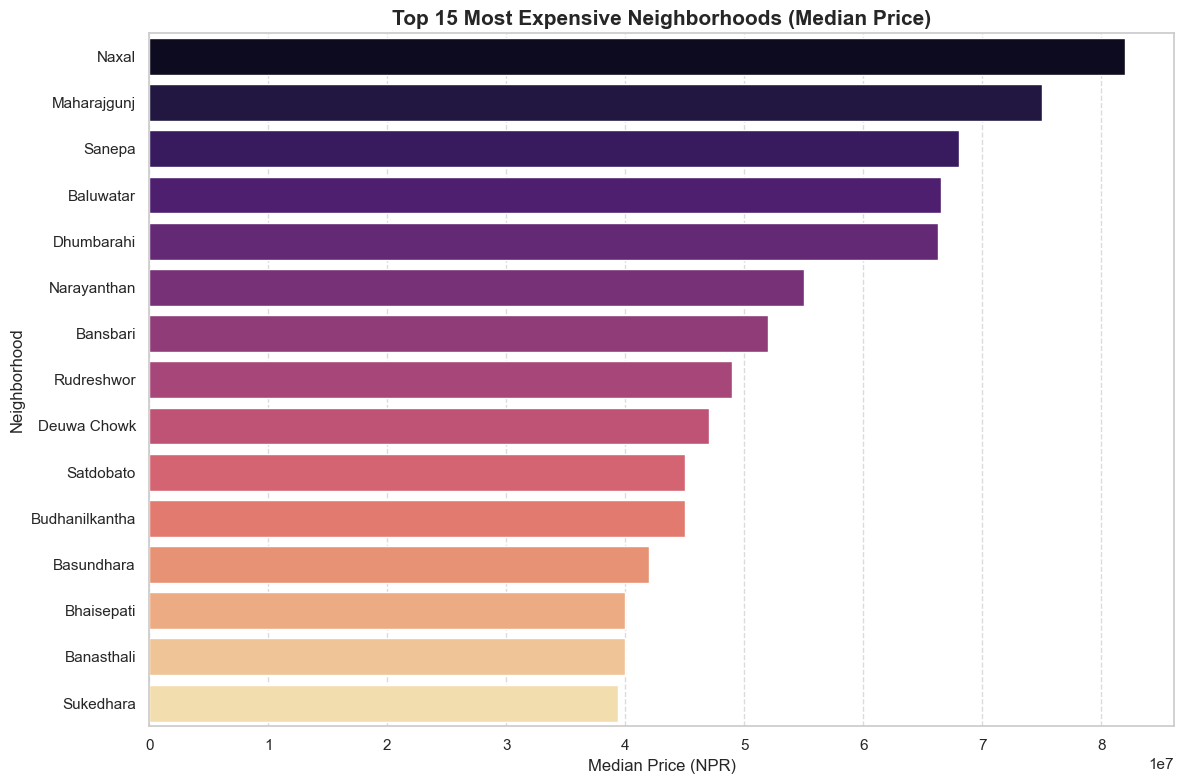

In [53]:


# 1. Filter for neighborhoods with enough data points (e.g., more than 10 listings)
top_n_counts = df['neighborhood'].value_counts()
popular_neighborhoods = top_n_counts[top_n_counts >= 10].index
df_filtered = df[df['neighborhood'].isin(popular_neighborhoods)]

# 2. Calculate median price per neighborhood to find the "Premium" ones
neighborhood_order = df_filtered.groupby('neighborhood')['total_price'].median().sort_values(ascending=False).index

# 3. Plotting the Top 15 Neighborhoods
plt.figure(figsize=(12, 8))
sns.barplot(
    data=df_filtered, 
    y='neighborhood', 
    x='total_price', 
    order=neighborhood_order[:15],  # Top 15 only for clarity
    estimator='median', 
    palette='magma',
    errorbar=None
)

plt.title('Top 15 Most Expensive Neighborhoods (Median Price)', fontsize=15, fontweight='bold')
plt.xlabel('Median Price (NPR)', fontsize=12)
plt.ylabel('Neighborhood', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_10352\1312006843.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='price_segment', y='land_area_aana', palette='coolwarm', ax=axes[0])
C:\Users\DELL\AppData\Local\Temp\ipykernel_10352\1312006843.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='price_segment', y='luxury_score', palette='viridis', ax=axes[1])


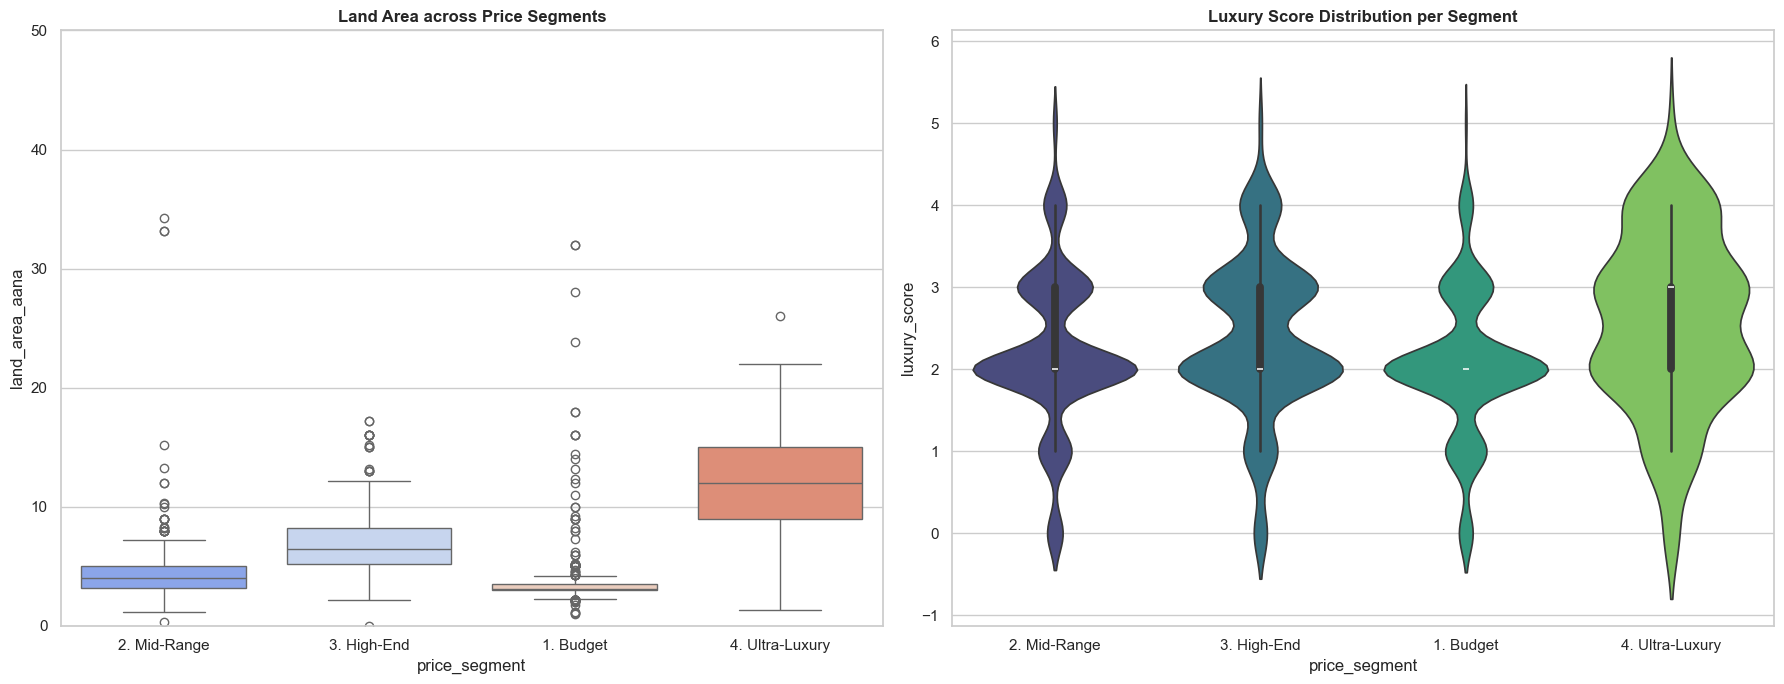

Budget: Below 24,500,000 NPR
Mid-Range: 24,500,000 to 45,000,000 NPR
High-End: 45,000,000 to 90,000,000 NPR
Ultra-Luxury: Above 90,000,000 NPR


In [54]:


# 1. Define Price Segments based on Percentiles
# Low (Bottom 25%), Mid (25%-75%), High (Top 25%), Ultra (Top 5%)
quantiles = df['total_price'].quantile([0.25, 0.75, 0.95])

def segment_price(price):
    if price <= quantiles[0.25]: return '1. Budget'
    elif price <= quantiles[0.75]: return '2. Mid-Range'
    elif price <= quantiles[0.95]: return '3. High-End'
    else: return '4. Ultra-Luxury'

df['price_segment'] = df['total_price'].apply(segment_price)

# 2. Plotting the Segments vs. Key Features
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot A: How Land Area changes per segment
sns.boxplot(data=df, x='price_segment', y='land_area_aana', palette='coolwarm', ax=axes[0])
axes[0].set_title('Land Area across Price Segments', fontweight='bold')
axes[0].set_ylim(0, 50) # Clipping for visibility

# Plot B: How Luxury Score changes per segment
sns.violinplot(data=df, x='price_segment', y='luxury_score', palette='viridis', ax=axes[1])
axes[1].set_title('Luxury Score Distribution per Segment', fontweight='bold')

plt.tight_layout()
plt.show()

# Print the segment boundaries for your notes
print(f"Budget: Below {quantiles[0.25]:,.0f} NPR")
print(f"Mid-Range: {quantiles[0.25]:,.0f} to {quantiles[0.75]:,.0f} NPR")
print(f"High-End: {quantiles[0.75]:,.0f} to {quantiles[0.95]:,.0f} NPR")
print(f"Ultra-Luxury: Above {quantiles[0.95]:,.0f} NPR")

# =============================================================================
# 📊 PRICE SEGMENT ANALYSIS — KEY CONCLUSIONS
# =============================================================================

# Price Segments defined:
# - Budget:       Below 2.45 Crore NPR
# - Mid-Range:    2.45 – 4.5 Crore NPR
# - High-End:     4.5 – 9 Crore NPR
# - Ultra-Luxury: Above 9 Crore NPR

# -----------------------------------------------------------------------------
# LAND AREA ACROSS PRICE SEGMENTS (Box Plot)
# -----------------------------------------------------------------------------
# - Budget:       Smallest land area — median ~3 aana, very tight distribution
#                 Many outliers above 15 aana (large cheap plots on outskirts)
# - Mid-Range:    Median ~4 aana, slightly larger than budget
# - High-End:     Median ~7 aana, noticeably more land than lower segments
# - Ultra-Luxury: Largest land — median ~12 aana, wide spread (10–22 aana)
#
# → Clear trend: higher price segment = more land area
# → Land area is a reliable indicator of which price segment a property belongs to
# → Budget properties with large land are likely in remote/underdeveloped areas
#    (explains the outliers in Budget segment above 15 aana)

# -----------------------------------------------------------------------------
# LUXURY SCORE ACROSS PRICE SEGMENTS (Violin Plot)
# -----------------------------------------------------------------------------
# - Budget:       Median luxury score ~2, narrow violin — most budget homes
#                 have similar (low) amenity levels, very little variation
# - Mid-Range:    Median ~2, slightly wider — some mid-range homes have
#                 more amenities but most are still clustered at score 2–3
# - High-End:     Similar median (~2) but wider spread — more variation in
#                 amenity quality within this segment
# - Ultra-Luxury: Widest violin — luxury score spreads from 0 to 5+
#                 Median still ~3 but distribution is much more varied
#
# → Surprising finding: luxury score medians are nearly the SAME across all segments
# → This confirms our earlier finding — luxury score is poorly designed
#    A truly luxury property should score much higher than a budget one
# → The wide spread in Ultra-Luxury shows some very expensive properties
#    actually have LOW amenity counts (land value drives price, not amenities)

# =============================================================================
# 🔑 OVERALL TAKEAWAYS
# =============================================================================
# 1. LAND AREA cleanly separates price segments — strongest segment indicator
# 2. LUXURY SCORE fails to separate segments — same median across all 4 groups
#    → Redesign luxury score or drop it as a pricing feature
# 3. BUDGET properties with high land area = outskirts/undeveloped locations
#    → Location matters more than size for budget segment
# 4. ULTRA-LUXURY price is driven by land size + location, NOT amenity count
# 5. These segments could be used as TARGET CLASSES for a classification model
#    as an alternative to regression-based price prediction
# 

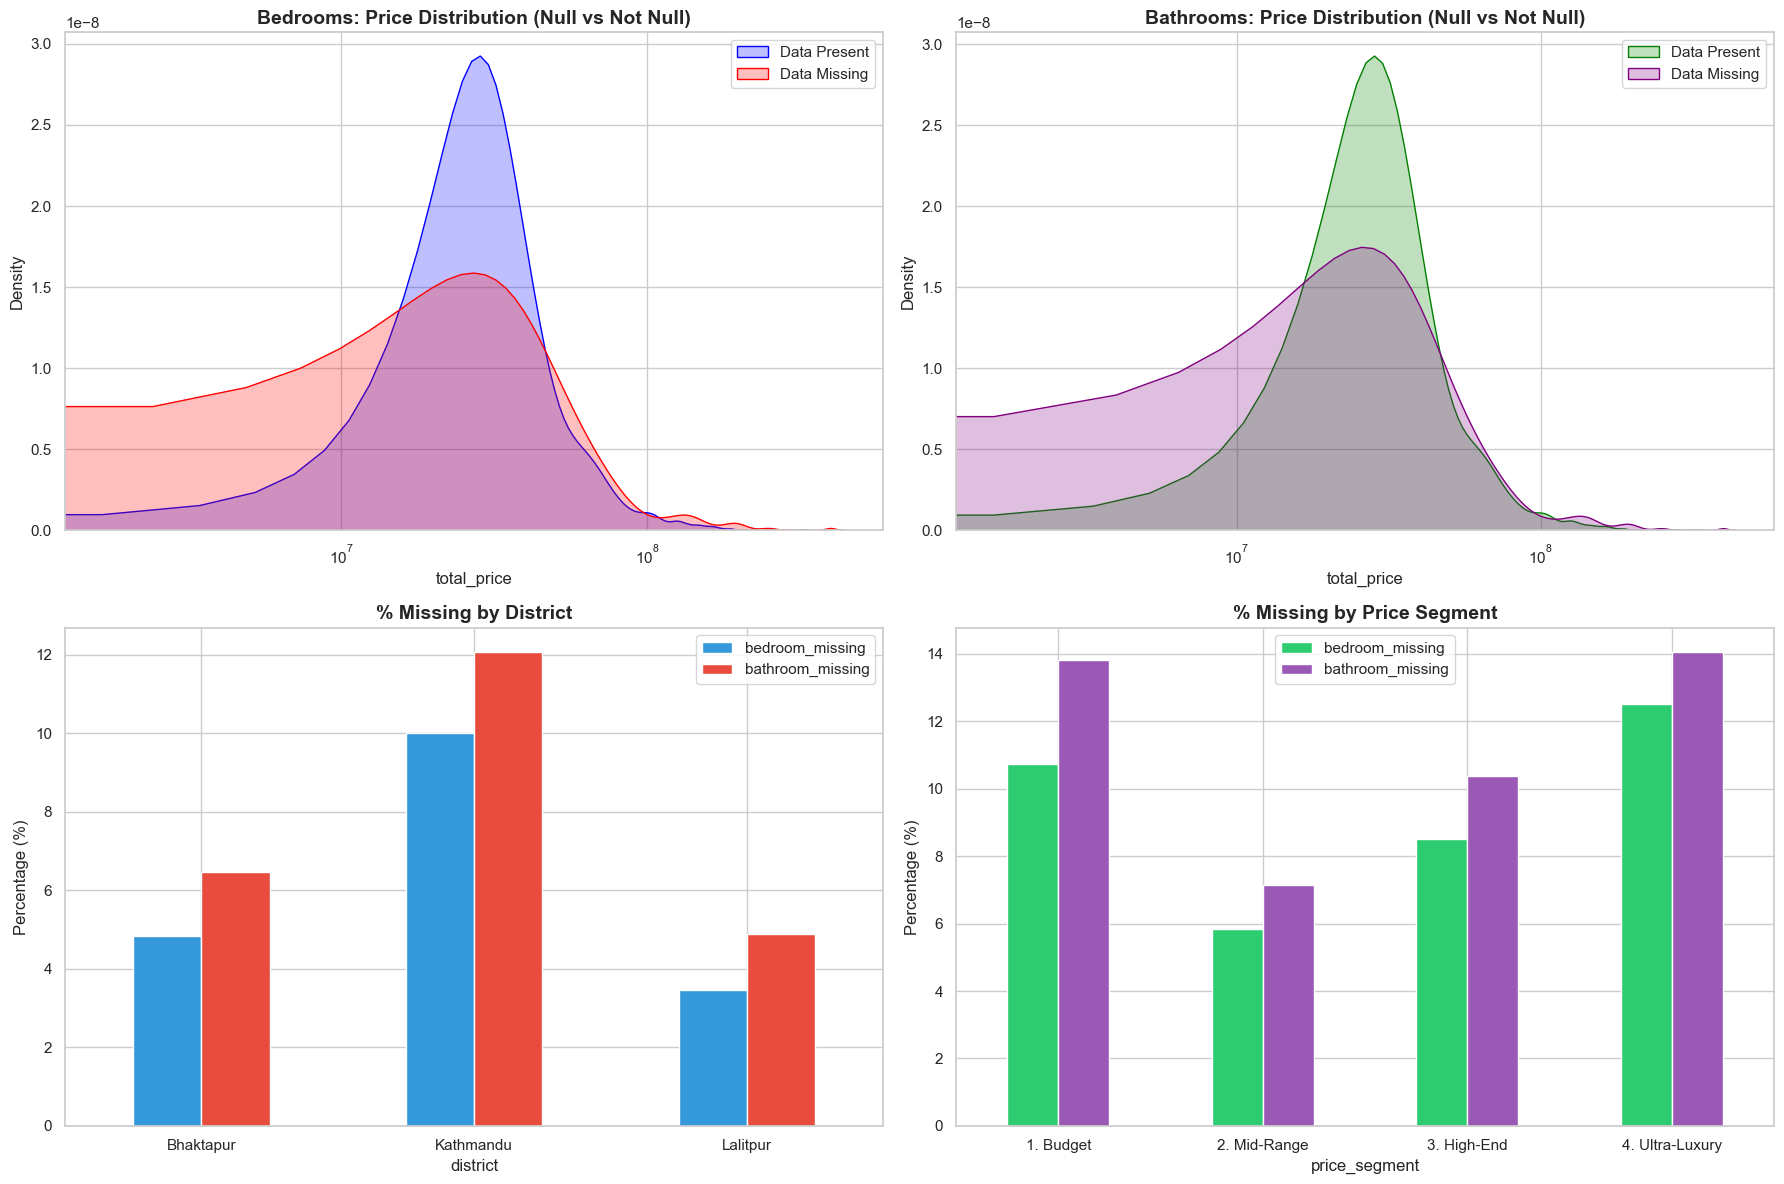

In [57]:


# 1. Flagging missing values
df['bedroom_missing'] = df['bedrooms'].isnull()
df['bathroom_missing'] = df['bathrooms'].isnull()

# 2. ANALYSIS 1: Spatial Pattern (By District)
missing_by_dist = df.groupby('district')[['bedroom_missing', 'bathroom_missing']].mean() * 100

# 3. ANALYSIS 2: Segment Pattern (By Price)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot A: Bedroom Price Distribution (Null vs Not Null)
sns.kdeplot(data=df[df['bedrooms'].notnull()], x='total_price', label='Data Present', fill=True, color='blue', ax=axes[0, 0])
sns.kdeplot(data=df[df['bedrooms'].isnull()], x='total_price', label='Data Missing', fill=True, color='red', ax=axes[0, 0])
axes[0, 0].set_xscale('log')
axes[0, 0].set_title('Bedrooms: Price Distribution (Null vs Not Null)', fontsize=14, fontweight='bold')
axes[0, 0].legend()

# Plot B: Bathroom Price Distribution (Null vs Not Null)
sns.kdeplot(data=df[df['bathrooms'].notnull()], x='total_price', label='Data Present', fill=True, color='green', ax=axes[0, 1])
sns.kdeplot(data=df[df['bathrooms'].isnull()], x='total_price', label='Data Missing', fill=True, color='purple', ax=axes[0, 1])
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('Bathrooms: Price Distribution (Null vs Not Null)', fontsize=14, fontweight='bold')
axes[0, 1].legend()

# Plot C: Missing Percentage by District
missing_by_dist.plot(kind='bar', ax=axes[1, 0], color=['#3498db', '#e74c3c'])
axes[1, 0].set_title('% Missing by District', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].tick_params(axis='x', rotation=0)

# Plot D: Missing Percentage by Price Segment
# (Using the price_segment logic we developed earlier)
missing_by_segment = df.groupby('price_segment')[['bedroom_missing', 'bathroom_missing']].mean() * 100
missing_by_segment.plot(kind='bar', ax=axes[1, 1], color=['#2ecc71', '#9b59b6'])
axes[1, 1].set_title('% Missing by Price Segment', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [60]:
df['price_segment'].value_counts()

price_segment
2. Mid-Range       1318
1. Budget           652
3. High-End         482
4. Ultra-Luxury     128
Name: count, dtype: int64

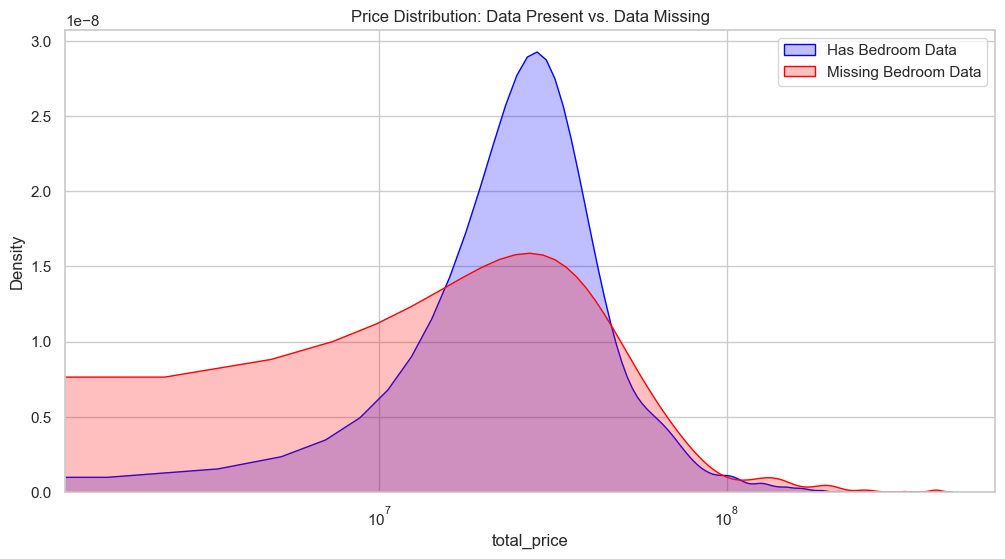